# Transfer Learning Exercise
Learning outcomes
* Practice implementing transfer learning by freezing the feature extractor, and by fine-tuning it.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

# Step 1: define all transforms first

MobileNetV2 expects colour input. This dataset contains images of greyscale letters. So we need to convert the greyscale images into colour ones. The single grayscale channel is copied into R, G and B, so the result is a 3-channel image where all channels are identical.

In [2]:
# ImageNet normalization
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Lambda(lambda img: img.convert("RGB")), # converting to RGB image
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# EMNIST Letters labels are 1-26 convert to 0-25
target_transform = lambda t: t - 1

# Step 2: Loading the data

In [3]:
# training data
trainset = torchvision.datasets.EMNIST(root="emnist",
                          split="letters",
                          train=True,
                          download=True,
                          transform=transform,
                          target_transform=target_transform)

100%|██████████| 562M/562M [00:02<00:00, 255MB/s]


In [4]:
# Testing data
testset = torchvision.datasets.EMNIST(root="emnist",
                          split="letters",
                          train=False,
                          download=True,
                          transform=transform,
                          target_transform=target_transform)

# Step 3: Set up the DataLoaders

In [5]:
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False)

## Detour step: Extracting a mini batch, to help get a sense of the contents of the data

In [6]:
# Get the first batch of data
images, labels = next(iter(trainloader))

print(f"Images tensor shape: {images.shape}")
print(f"Labels tensor shape: {labels.shape}")
print(f"Labels in this batch: {labels}")

Images tensor shape: torch.Size([64, 3, 224, 224])
Labels tensor shape: torch.Size([64])
Labels in this batch: tensor([12, 25, 11, 14, 16, 21, 25, 13,  0, 24, 23, 21, 11,  1,  3, 18, 14,  9,
         0, 12, 14, 14,  4, 21,  3, 17, 13, 25, 13, 12,  3, 15,  0,  0,  1, 11,
         6, 13,  9, 13, 13, 16,  5, 10,  8, 11, 11, 16,  8, 18, 24,  0, 15, 17,
         1, 21, 10, 21,  1, 12, 13,  5,  8,  5])


## Viewing an example

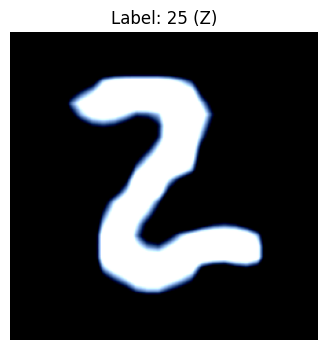

In [7]:
image_index = 1
img = images[image_index]            # shape [3,224,224] or [3,H,W]
if img.device.type != 'cpu':
    img = img.cpu()

# convert C,H,W -> H,W,C for matplotlib
img_np = img.permute(2, 1, 0).numpy()

plt.figure(figsize=(4,4))
plt.imshow(img_np)
label = labels[image_index].item()
letter = chr(ord('A') + label)
plt.title(f'Label: {label} ({letter})')
plt.axis('off')
plt.show()

# Part 1 (freezing feature extractor)

# Task 1: Download the MobileNet V2 network


In [8]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s]


# Task 2: freeze the feature extractor


In [9]:
#set features from mobinenet to var
features = mobilenet.features

#freeze the features in this new var
for param in features.parameters():
  param.requires_grad = False

# Create some data data and pass it through the feature extractor so that you know what the output of the feature extractor is.


In [10]:
dummy = torch.zeros(1, 3, 224, 224)  # use the input resolution you expect

Perform a forward pass through the feature extractor

In [11]:
with torch.no_grad():
    output = features(dummy)

print(output.shape)

torch.Size([1, 1280, 7, 7])


# Task3: Create a new classifier head

In [12]:
classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280 * 7 * 7, 512),
    nn.ReLU(),
    nn.Linear(512, 26)
)

# Task 4: Create a class called MyMNV2 which extends from ``nn.Module``.

In [13]:
class MyMNV2(nn.Module):
    def __init__(self, features, classifier):
        super().__init__()

        self.features = features
        self.classifier = classifier

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
model = MyMNV2(features, classifier)

# Task: Set up loss function and optimiser

* use a learning rate of 0.001

* Use the Adam optimiser.

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# Task: train for 3 epochs

* Run on a GPU (G4) for faster run time

In [16]:
# Determine if we're going to work on CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Send model to GPU if available
model.to(device)

for epoch in range(3):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(trainloader, desc='Training'):

        # Send mini-batch to GPU is available
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

Training: 100%|██████████| 1950/1950 [05:57<00:00,  5.46it/s]


Epoch 1, Loss: 1106.365


Training: 100%|██████████| 1950/1950 [05:57<00:00,  5.45it/s]


Epoch 2, Loss: 540.500


Training: 100%|██████████| 1950/1950 [05:57<00:00,  5.45it/s]

Epoch 3, Loss: 485.193


# Determine the test accuracy

In [17]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in tqdm(testloader, desc='Inference'):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Inference: 100%|██████████| 325/325 [00:52<00:00,  6.20it/s]

Accuracy: 88.98%


# Part 2 (fine-tuning)

# Task: re-initialise fine-tuned model


In [18]:
mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
features = mobilenet.features

In [19]:
for param in features.parameters():
    param.requires_grad = True #unfreeze the features

In [20]:
classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280 * 7 * 7, 512),
    nn.ReLU(),
    nn.Linear(512, 26)
)

In [21]:
network = MyMNV2(features, classifier)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([ #differential learning
    {"params": network.features.parameters(), "lr": 1e-5},
    {"params": network.classifier.parameters(), "lr": 1e-3}])

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Send model to GPU if available
network.to(device)

for epoch in range(3):
    network.train()
    running_loss = 0.0

    for images, labels in tqdm(trainloader, desc='Training'):

        # Send mini-batch to GPU is available
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = network(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

Training: 100%|██████████| 1950/1950 [11:32<00:00,  2.81it/s]


Epoch 1, Loss: 1032.917


Training: 100%|██████████| 1950/1950 [11:32<00:00,  2.81it/s]


Epoch 2, Loss: 412.866


Training: 100%|██████████| 1950/1950 [11:32<00:00,  2.81it/s]

Epoch 3, Loss: 363.932


# Execute code below and determine the test accuracy

In [24]:
correct = 0
total = 0

network.eval()
with torch.no_grad():
    for images, labels in tqdm(testloader, desc='Inference'):
        images, labels = images.to(device), labels.to(device)

        outputs = network(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Inference: 100%|██████████| 325/325 [00:53<00:00,  6.12it/s]

Accuracy: 92.55%
